In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

import joblib

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch Embarked            Ticket     Fare Cabin  PassengerId  Pclass  \
0      0        S         A/5 21171   7.2500   NaN            1       3   
1      0        C          PC 17599  71.2833   C85            2       1   
2      0        S  STON/O2. 3101282   7.9250   NaN            3       3   
3      0        S            113803  53.1000  C123            4       1   
4      0        S            373450   8.0500   NaN            5       3   

   Survived  
0         0  
1         1  
2         1  
3         1  
4         0  
(8

In [3]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


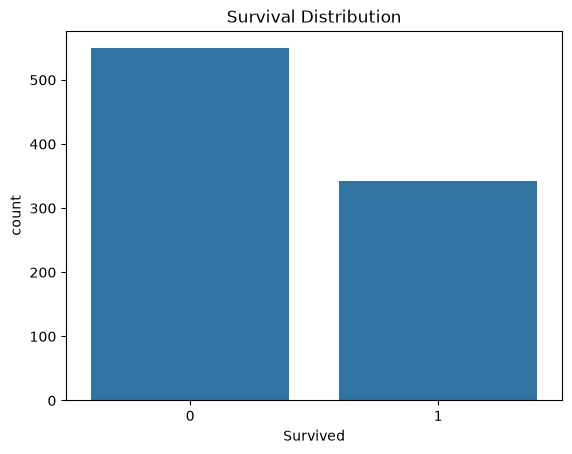

In [4]:
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

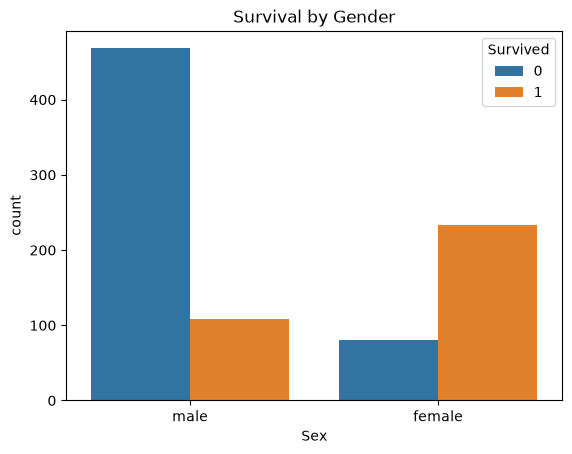

In [5]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

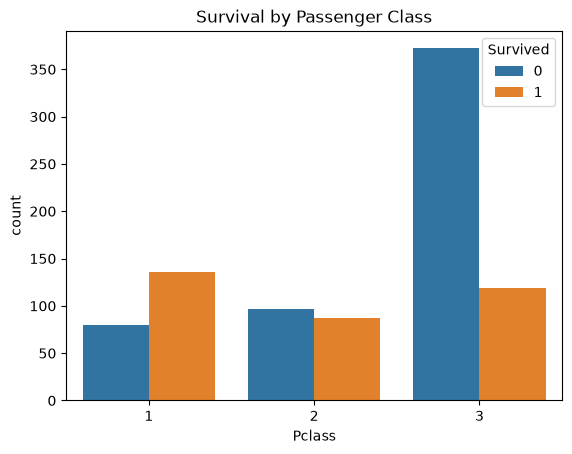

In [6]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

In [7]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [9]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

In [10]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [12]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [13]:
logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
Accuracy: 0.8044692737430168
Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1 Score: 0.7244094488188977
ROC-AUC: 0.8437417654808959


In [14]:
decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

In [15]:
decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Decision Tree
Accuracy: 0.7653631284916201
Precision: 0.7547169811320755
Recall: 0.5797101449275363
F1 Score: 0.6557377049180327
ROC-AUC: 0.7971014492753623


In [16]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

In [17]:
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest
Accuracy: 0.8100558659217877
Precision: 0.7966101694915254
Recall: 0.6811594202898551
F1 Score: 0.734375
ROC-AUC: 0.828722002635046


In [18]:
gradient_boosting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

In [19]:
gradient_boosting.fit(X_train, y_train)

y_pred_gb = gradient_boosting.predict(X_test)
y_prob_gb = gradient_boosting.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting
Accuracy: 0.7988826815642458
Precision: 0.7894736842105263
Recall: 0.6521739130434783
F1 Score: 0.7142857142857143
ROC-AUC: 0.8179183135704875


In [20]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

In [21]:
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost
Accuracy: 0.7877094972067039
Precision: 0.7627118644067796
Recall: 0.6521739130434783
F1 Score: 0.703125
ROC-AUC: 0.8190382081686429


In [22]:
ml_results = []

for name, model in {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
    "XGBoost": xgb_model
}.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ml_results_df = pd.DataFrame(ml_results)

print(ml_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.787709   0.762712  0.652174  0.703125  0.819038


In [23]:
ml_results_df = ml_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

ml_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.810056,0.796610,0.681159,0.734375,0.828722
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
3,Gradient Boosting,0.798883,0.789474,0.652174,0.714286,0.817918
4,XGBoost,0.787709,0.762712,0.652174,0.703125,0.819038
1,Decision Tree,0.765363,0.754717,0.579710,0.655738,0.797101


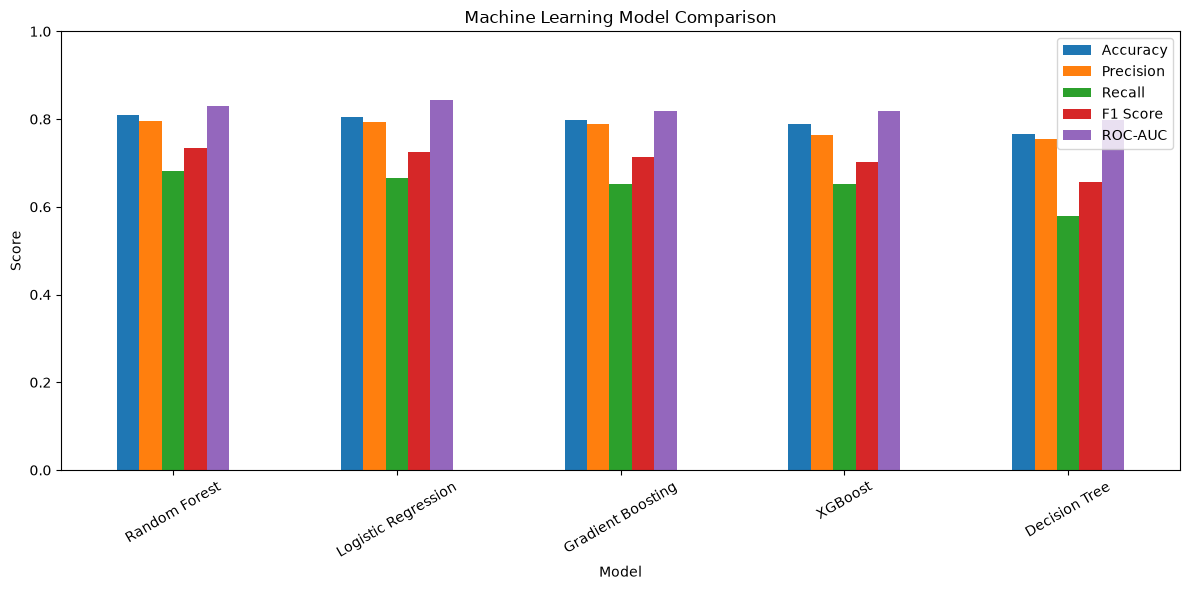

In [24]:
ml_results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [25]:
dl_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

dl_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

dl_preprocessor = ColumnTransformer([
    ("num", dl_numeric, numeric_features),
    ("cat", dl_categorical, categorical_features)
])

In [28]:
X_train_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)

print("Training shape:", X_train_dl.shape)
print("Testing shape:", X_test_dl.shape)

Training shape: (712, 10)
Testing shape: (179, 10)


In [29]:
dl_preprocessor.fit_transform(X_train)

array([[ 0.82956755, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  1.        ],
       [-0.37094484, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  1.        ],
       [-1.57145722, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.82956755,  1.41700669,  0.47833454, ...,  0.        ,
         0.        ,  1.        ],
       [-1.57145722,  1.34017889, -0.46508428, ...,  0.        ,
         0.        ,  1.        ],
       [-1.57145722, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  1.        ]], shape=(712, 10))

In [30]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [31]:
ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_dl.shape[1],)),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

c:\Users\amuly\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
ann_history = ann_model.fit(
    X_train_dl,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5431 - loss: 0.6892 - val_accuracy: 0.7133 - val_loss: 0.6475
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7047 - loss: 0.6391 - val_accuracy: 0.7413 - val_loss: 0.6100
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7452 - loss: 0.5966 - val_accuracy: 0.7483 - val_loss: 0.5655
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7680 - loss: 0.5608 - val_accuracy: 0.7692 - val_loss: 0.5192
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7610 - loss: 0.5193 - val_accuracy: 0.7762 - val_loss: 0.4831
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7961 - loss: 0.4694 - val_accuracy: 0.7972 - val_loss: 0.4568
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7961 - loss: 0.4612 - val_accuracy: 0.7972 - val_loss: 0.4475
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8014 - loss: 0.4643 - val_accuracy: 0.8182 - val_loss

In [33]:
ann_prob = ann_model.predict(X_test_dl).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

ann_results = {
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, ann_pred),
    "Precision": precision_score(y_test, ann_pred),
    "Recall": recall_score(y_test, ann_pred),
    "F1 Score": f1_score(y_test, ann_pred),
    "ROC-AUC": roc_auc_score(y_test, ann_prob)
}

print(ann_results)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
{'Model': 'ANN', 'Accuracy': 0.8100558659217877, 'Precision': 0.8431372549019608, 'Recall': 0.6231884057971014, 'F1 Score': 0.7166666666666667, 'ROC-AUC': 0.8587615283267458}


In [34]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

In [35]:
X_train_cnn = X_train_dl.reshape(
    X_train_dl.shape[0],
    X_train_dl.shape[1],
    1
)

X_test_cnn = X_test_dl.reshape(
    X_test_dl.shape[0],
    X_test_dl.shape[1],
    1
)

print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: (712, 10, 1)
CNN testing shape: (179, 10, 1)


In [36]:
cnn_model = Sequential([
    Conv1D(
        32,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train_cnn.shape[1], 1)
    ),
    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation="relu"
    ),

    Flatten(),

    Dense(32, activation="relu"),
    Dropout(0.30),

    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

c:\Users\amuly\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,497 (41.00 KB)

 Trainable params: 10,497 (41.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6678 - loss: 0.6531 - val_accuracy: 0.7552 - val_loss: 0.6140
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7329 - loss: 0.5876 - val_accuracy: 0.7552 - val_loss: 0.5328
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7698 - loss: 0.5244 - val_accuracy: 0.8252 - val_loss: 0.4802
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7610 - loss: 0.5027 - val_accuracy: 0.8112 - val_loss: 0.4549
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7680 - loss: 0.4734 - val_accuracy: 0.8112 - val_loss: 0.4470
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7856 - loss: 0.4575 - val_accuracy: 0.8112 - val_loss: 0.4461
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7821 - loss: 0.4566 - val_accuracy: 0.8112 - val_loss: 0.4432
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7873 - loss: 0.4503 - val_accuracy: 0.8042 - val_loss

In [38]:
cnn_prob = cnn_model.predict(X_test_cnn).ravel()
cnn_pred = (cnn_prob >= 0.5).astype(int)

cnn_results = {
    "Model": "1D CNN",
    "Accuracy": accuracy_score(y_test, cnn_pred),
    "Precision": precision_score(y_test, cnn_pred),
    "Recall": recall_score(y_test, cnn_pred),
    "F1 Score": f1_score(y_test, cnn_pred),
    "ROC-AUC": roc_auc_score(y_test, cnn_prob)
}

print(cnn_results)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
{'Model': '1D CNN', 'Accuracy': 0.7597765363128491, 'Precision': 0.703125, 'Recall': 0.6521739130434783, 'F1 Score': 0.6766917293233082, 'ROC-AUC': 0.8432147562582346}


In [39]:
dl_results_df = pd.DataFrame([
    ann_results,
    cnn_results
])

print(dl_results_df)

    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0     ANN  0.810056   0.843137  0.623188  0.716667  0.858762
1  1D CNN  0.759777   0.703125  0.652174  0.676692  0.843215


In [40]:
all_results = pd.concat(
    [ml_results_df, dl_results_df],
    ignore_index=True
)

print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
1  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
2    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
3              XGBoost  0.787709   0.762712  0.652174  0.703125  0.819038
4        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
5                  ANN  0.810056   0.843137  0.623188  0.716667  0.858762
6               1D CNN  0.759777   0.703125  0.652174  0.676692  0.843215


In [41]:
all_results = all_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
1  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
5                  ANN  0.810056   0.843137  0.623188  0.716667  0.858762
2    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
3              XGBoost  0.787709   0.762712  0.652174  0.703125  0.819038
6               1D CNN  0.759777   0.703125  0.652174  0.676692  0.843215
4        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


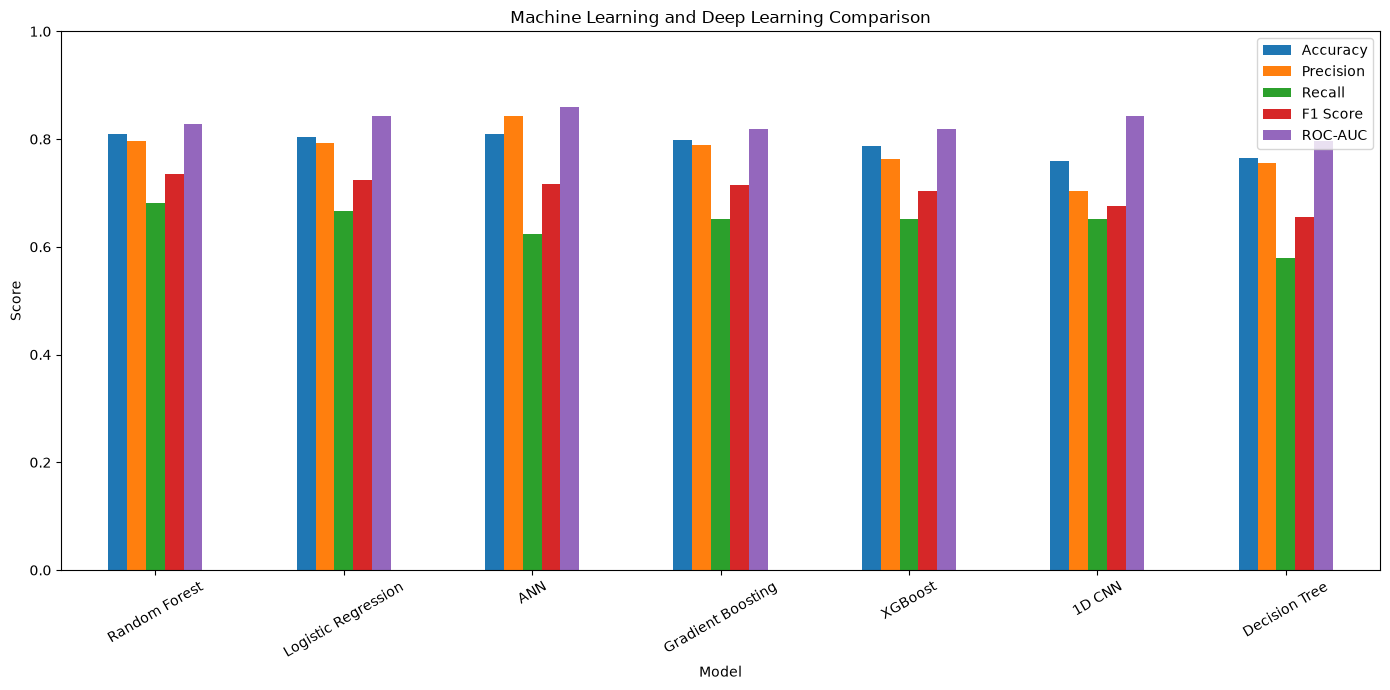

In [42]:
all_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Machine Learning and Deep Learning Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [43]:
best_model_name = all_results.iloc[0]["Model"]

print("Best model based on F1 Score:", best_model_name)

Best model based on F1 Score: Random Forest


In [44]:
ml_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
    "XGBoost": xgb_model
}

print("ML models ready.")

ML models ready.


In [45]:
print("Selected model:", best_model_name)

Selected model: Random Forest


In [46]:
if best_model_name in ml_models:
    best_ml_model = ml_models[best_model_name]

    joblib.dump(
        best_ml_model,
        "titanic_best_model.pkl"
    )

    print("Model saved successfully as titanic_best_model.pkl")
else:
    print(
        "The selected model is a Deep Learning model:",
        best_model_name
    )
    print("The PDF's joblib example is for ML pipelines.")

Model saved successfully as titanic_best_model.pkl


In [47]:
print("Selected model:", best_model_name)

Selected model: Random Forest


In [48]:
best_ml_model = ml_models[best_model_name]

best_pred = best_ml_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Confusion Matrix:
[[98 12]
 [22 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [49]:
best_pred = ann_pred

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Confusion Matrix:
[[102   8]
 [ 26  43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



In [50]:
best_pred = ann_pred

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Confusion Matrix:
[[102   8]
 [ 26  43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



In [51]:
best_pred = cnn_pred

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Confusion Matrix:
[[91 19]
 [24 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       110
           1       0.70      0.65      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



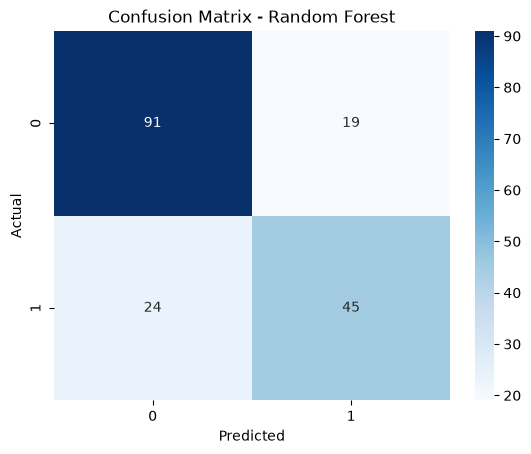

In [52]:
cm = confusion_matrix(y_test, best_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
best_ml_model = ml_models[best_model_name]

model = best_ml_model.named_steps["model"]
preprocessor_used = best_ml_model.named_steps["preprocessor"]

feature_names = preprocessor_used.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(
        by="Importance",
        ascending=False
    )

    print(feature_importance_df)
else:
    print("This model does not provide feature_importances_.")

           Feature  Importance
4        num__Fare    0.257490
1         num__Age    0.243869
6    cat__Sex_male    0.153717
5  cat__Sex_female    0.136457
0      num__Pclass    0.087248
2       num__SibSp    0.046531
3       num__Parch    0.038527
9  cat__Embarked_S    0.016330
7  cat__Embarked_C    0.012098
8  cat__Embarked_Q    0.007733


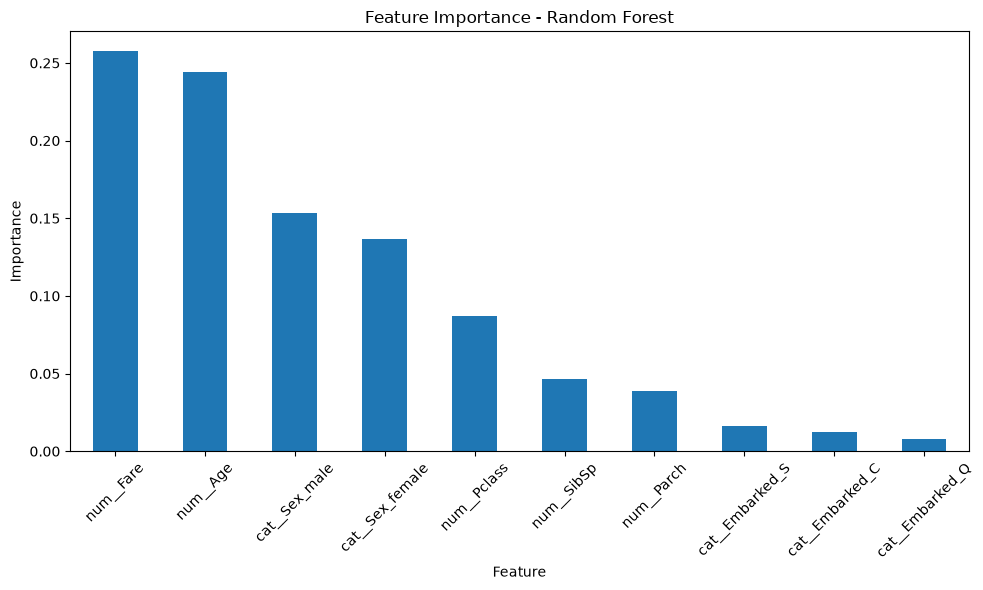

In [54]:
feature_importance_df.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
print("Selected model:", best_model_name)

Selected model: Random Forest


In [56]:
print("FINAL MODEL COMPARISON")
print("=" * 60)

display(
    all_results[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ]
)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.810056,0.796610,0.681159,0.734375,0.828722
1,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
5,ANN,0.810056,0.843137,0.623188,0.716667,0.858762
2,Gradient Boosting,0.798883,0.789474,0.652174,0.714286,0.817918
3,XGBoost,0.787709,0.762712,0.652174,0.703125,0.819038
6,1D CNN,0.759777,0.703125,0.652174,0.676692,0.843215
4,Decision Tree,0.765363,0.754717,0.579710,0.655738,0.797101


In [57]:
print("Selected Model:", best_model_name)

Selected Model: Random Forest


In [58]:
print("FINAL EVALUATION")
print("=" * 60)

print("Model:", best_model_name)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

FINAL EVALUATION
Model: Random Forest

Confusion Matrix:
[[91 19]
 [24 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       110
           1       0.70      0.65      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



In [59]:
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    all_results[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ].round(4)
)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8101,0.7966,0.6812,0.7344,0.8287
1,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
5,ANN,0.8101,0.8431,0.6232,0.7167,0.8588
2,Gradient Boosting,0.7989,0.7895,0.6522,0.7143,0.8179
3,XGBoost,0.7877,0.7627,0.6522,0.7031,0.8190
6,1D CNN,0.7598,0.7031,0.6522,0.6767,0.8432
4,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971


In [60]:
print("Selected Model:", best_model_name)

Selected Model: Random Forest


In [61]:
print("Random Forest Evaluation")
print("=" * 50)

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Random Forest Evaluation
Confusion Matrix:
[[91 19]
 [24 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       110
           1       0.70      0.65      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



In [62]:
display(
    all_results[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ].round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8101,0.7966,0.6812,0.7344,0.8287
1,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
5,ANN,0.8101,0.8431,0.6232,0.7167,0.8588
2,Gradient Boosting,0.7989,0.7895,0.6522,0.7143,0.8179
3,XGBoost,0.7877,0.7627,0.6522,0.7031,0.8190
6,1D CNN,0.7598,0.7031,0.6522,0.6767,0.8432
4,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971


In [63]:
# Recalculate Random Forest predictions directly
rf_model = ml_models["Random Forest"]

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Random Forest Precision:",
      precision_score(y_test, rf_pred))

print("Random Forest Recall:",
      recall_score(y_test, rf_pred))

print("Random Forest F1 Score:",
      f1_score(y_test, rf_pred))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8100558659217877
Random Forest Precision: 0.7966101694915254
Random Forest Recall: 0.6811594202898551
Random Forest F1 Score: 0.734375
Random Forest ROC-AUC: 0.828722002635046

Confusion Matrix:
[[98 12]
 [22 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [64]:
rf_model = ml_models["Random Forest"]

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Random Forest Precision:",
      precision_score(y_test, rf_pred))

print("Random Forest Recall:",
      recall_score(y_test, rf_pred))

print("Random Forest F1 Score:",
      f1_score(y_test, rf_pred))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8100558659217877
Random Forest Precision: 0.7966101694915254
Random Forest Recall: 0.6811594202898551
Random Forest F1 Score: 0.734375
Random Forest ROC-AUC: 0.828722002635046

Confusion Matrix:
[[98 12]
 [22 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

